## Module 5(2) - Ensemble Models
Asst. Prof. Dr. Santitham Prom-on

---

# 1. Load data

In [1]:
# In local environment, data is pre-saved from Module 5(1) as ML_5_hr_attrition.data
# !wget https://github.com/santitham/data-science/raw/refs/heads/main/data/hr_attrition.data

In [2]:
import pickle
import os

data_file = 'ML_5_hr_attrition.data' if os.path.exists('ML_5_hr_attrition.data') else 'hr_attrition.data'
X_train, X_test, y_train, y_test = pickle.load(open(data_file, 'rb'))
print(f"Loaded training data from {data_file}")

Loaded training data from ML_5_hr_attrition.data


In [3]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1029, 44)
(441, 44)
(1029,)
(441,)


# 2. Modeling - Random Forest

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(min_samples_leaf=20, max_depth=8, class_weight='balanced')
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [5]:
import pandas as pd

pd.DataFrame(dict(Feature=rf.feature_names_in_,
                  Value=rf.feature_importances_))\
  .sort_values(by='Value', ascending=False)\
  .head(20)

,Feature,Value
30,MonthlyIncome,0.116988
20,OverTime_Yes,0.094258
36,StockOptionLevel,0.058293
40,YearsAtCompany,0.052758
21,Age,0.052106
43,YearsWithCurrManager,0.048563
22,DailyRate,0.047893
41,YearsInCurrentRole,0.041287
28,JobLevel,0.040361
37,TotalWorkingYears,0.038645


In [6]:
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


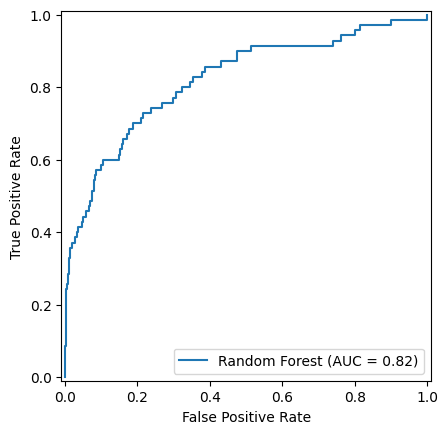

In [7]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

y_res = rf.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_res[:,1])
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Random Forest')
display.plot()

In [8]:
import os
import pandas as pd
bank_file = 'ML_5_bank-data.csv' if os.path.exists('ML_5_bank-data.csv') else 'http://fastdata.in.th/GSB/bank-data.csv'
df = pd.read_csv(bank_file, sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [9]:
# 1. separate numeric data
df_num = df.select_dtypes('number')
df_num.drop(columns='duration', inplace=True)
df_num

,age,balance,day,campaign,pdays,previous
0,30,1787,19,1,-1,0
1,33,4789,11,1,339,4
2,35,1350,16,1,330,1
3,30,1476,3,4,-1,0
4,59,0,5,1,-1,0
...,...,...,...,...,...,...
4516,33,-333,30,5,-1,0
4517,57,-3313,9,1,-1,0
4518,57,295,19,11,-1,0
4519,28,1137,6,4,211,3


In [10]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4521.0,41.170095,10.576211,19.0,33.0,39.0,49.0,87.0
balance,4521.0,1422.657819,3009.638142,-3313.0,69.0,444.0,1480.0,71188.0
day,4521.0,15.915284,8.247667,1.0,9.0,16.0,21.0,31.0
campaign,4521.0,2.793630,3.109807,1.0,1.0,2.0,3.0,50.0
pdays,4521.0,39.766645,100.121124,-1.0,-1.0,-1.0,-1.0,871.0
previous,4521.0,0.542579,1.693562,0.0,0.0,0.0,0.0,25.0


In [11]:
df_cat = df.select_dtypes('object')
df_cat

,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,unemployed,married,primary,no,no,no,cellular,oct,unknown,no
1,services,married,secondary,no,yes,yes,cellular,may,failure,no
2,management,single,tertiary,no,yes,no,cellular,apr,failure,no
3,management,married,tertiary,no,yes,yes,unknown,jun,unknown,no
4,blue-collar,married,secondary,no,yes,no,unknown,may,unknown,no
...,...,...,...,...,...,...,...,...,...,...
4516,services,married,secondary,no,yes,no,cellular,jul,unknown,no
4517,self-employed,married,tertiary,yes,yes,yes,unknown,may,unknown,no
4518,technician,married,secondary,no,no,no,cellular,aug,unknown,no
4519,blue-collar,married,secondary,no,no,no,cellular,feb,other,no


In [12]:
df_cat_bin = pd.get_dummies(df_cat, drop_first=True)
df_cat_bin

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,y_yes
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4517,False,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4518,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4519,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [13]:
# 4. combine data
df_prep = pd.concat([df_num, df_cat_bin], axis=1)
df_prep

,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,y_yes
0,30,1787,19,1,-1,0,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,33,4789,11,1,339,4,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,35,1350,16,1,330,1,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,30,1476,3,4,-1,0,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,59,0,5,1,-1,0,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,-333,30,5,-1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4517,57,-3313,9,1,-1,0,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4518,57,295,19,11,-1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4519,28,1137,6,4,211,3,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [14]:
pd.crosstab(df_prep['y_yes'], columns='N', normalize=True)

col_0,N
y_yes,
False,0.88476
True,0.11524


In [15]:
X = df_prep.drop(columns='y_yes')
y = df_prep['y_yes']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=777)

In [17]:
pd.crosstab(y_train, columns='N', normalize=True)

col_0,N
y_yes,
False,0.879899
True,0.120101


In [18]:
pd.crosstab(y_test, columns='N', normalize=True)

col_0,N
y_yes,
False,0.896094
True,0.103906


In [19]:
model = RandomForestClassifier(n_estimators=500,max_samples=0.5,class_weight='balanced')
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


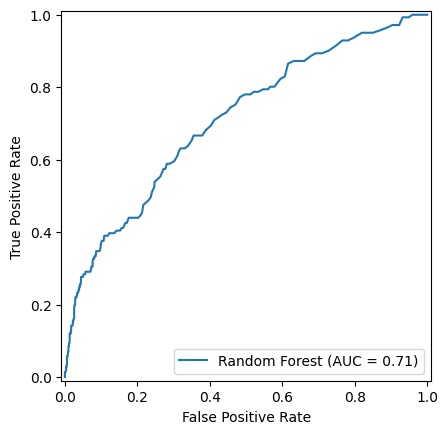

In [20]:
y_res = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_res[:,1])
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Random Forest')
display.plot()

In [21]:
pd.DataFrame({'Feature':model.feature_names_in_,
              'Score':model.feature_importances_})\
  .sort_values(by='Score', ascending=False)\
  .head(20)

,Feature,Score
1,balance,0.149743
0,age,0.130045
2,day,0.117431
3,campaign,0.069766
4,pdays,0.042256
26,contact_unknown,0.032737
39,poutcome_success,0.032593
5,previous,0.029080
23,housing_yes,0.026146
19,education_secondary,0.022178


# 3. Gradient Boosting

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(min_samples_leaf=20, n_estimators=200)
gbc.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [23]:
import pandas as pd

pd.DataFrame(dict(Feature=gbc.feature_names_in_,
                  Value=gbc.feature_importances_))\
  .sort_values(by='Value', ascending=False)\
  .head(20)

,Feature,Value
39,poutcome_success,0.251636
1,balance,0.128564
0,age,0.107106
4,pdays,0.102109
2,day,0.083334
36,month_oct,0.056754
32,month_jun,0.040106
33,month_mar,0.027513
26,contact_unknown,0.026894
3,campaign,0.026618


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


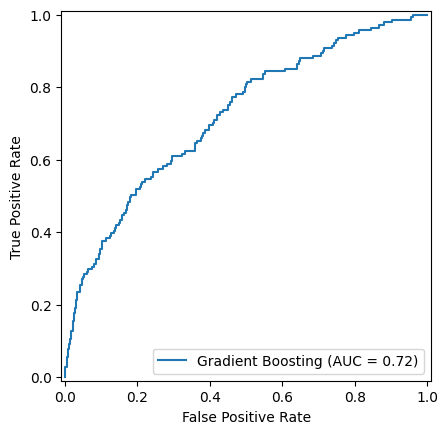

In [24]:
y_res = gbc.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_res[:,1])
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Gradient Boosting')
display.plot()

# 4. xgBoost

In [25]:
import xgboost as xgb

param = {
    'eta': 0.3,
    'max_depth': 6,
    'objective': 'binary:logistic'
}

steps = 100

In [26]:
D_train = xgb.DMatrix(X_train, label=y_train)
D_test = xgb.DMatrix(X_test, label=y_test)

In [27]:
model = xgb.train(param, D_train, steps)

In [28]:
model

In [29]:
p = model.predict(D_test)
p

array([0.00229006, 0.00099255, 0.00211669, ..., 0.01782905, 0.03912866,
       0.00512912], shape=(1357,), dtype=float32)

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


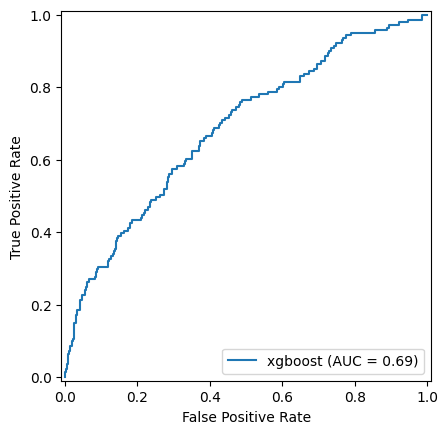

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, p)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='xgboost')
display.plot()

In [31]:
model.get_score(importance_type='total_gain')

{'age': 508.3587341308594,
 'balance': 665.1718139648438,
 'day': 425.828857421875,
 'campaign': 217.71836853027344,
 'pdays': 211.0534210205078,
 'previous': 73.28965759277344,
 'job_blue-collar': 34.4361686706543,
 'job_entrepreneur': 5.150881290435791,
 'job_housemaid': 13.11838150024414,
 'job_management': 28.07496452331543,
 'job_retired': 21.005144119262695,
 'job_self-employed': 9.877520561218262,
 'job_services': 5.728487014770508,
 'job_student': 5.1839141845703125,
 'job_technician': 24.52274513244629,
 'job_unemployed': 6.561903953552246,
 'job_unknown': 0.7584064602851868,
 'marital_married': 38.036617279052734,
 'marital_single': 33.39292907714844,
 'education_secondary': 50.176639556884766,
 'education_tertiary': 36.68119812011719,
 'education_unknown': 11.488893508911133,
 'default_yes': 7.933529376983643,
 'housing_yes': 78.5204086303711,
 'loan_yes': 31.66025733947754,
 'contact_telephone': 19.408071517944336,
 'contact_unknown': 101.12923431396484,
 'month_aug': 14.65

In [32]:
sorted(model.get_score(importance_type='total_gain').items(),
       key = lambda x:x[1], reverse = True)

[('balance', 665.1718139648438),
 ('age', 508.3587341308594),
 ('day', 425.828857421875),
 ('poutcome_success', 358.92254638671875),
 ('campaign', 217.71836853027344),
 ('pdays', 211.0534210205078),
 ('contact_unknown', 101.12923431396484),
 ('month_oct', 95.16925048828125),
 ('housing_yes', 78.5204086303711),
 ('month_jun', 77.63701629638672),
 ('previous', 73.28965759277344),
 ('month_feb', 54.30419921875),
 ('education_secondary', 50.176639556884766),
 ('marital_married', 38.036617279052734),
 ('education_tertiary', 36.68119812011719),
 ('month_may', 35.92216873168945),
 ('month_mar', 35.873741149902344),
 ('job_blue-collar', 34.4361686706543),
 ('marital_single', 33.39292907714844),
 ('loan_yes', 31.66025733947754),
 ('month_nov', 28.259370803833008),
 ('job_management', 28.07496452331543),
 ('month_jul', 27.458450317382812),
 ('job_technician', 24.52274513244629),
 ('job_retired', 21.005144119262695),
 ('poutcome_other', 20.597949981689453),
 ('contact_telephone', 19.4080715179443